# Dial Studies -- Diagnosing the Q2 Sideband Leakage

**Purpose:** not a fix -- a diagnostic. We are NOT adding a new dial right now. The goal is to identify *which existing nuisance parameter(s)* are compensating for the injected Q2-shaped suppression, and how hard they're straining to do it, so the leakage mechanism is understood precisely before deciding what (if anything) to build.

**Logic:** compare each cross-section systematic's postfit pull between two fits:
- **Asimov** (`Asimov`/`Asimov_Containment`): nominal MC vs nominal MC. Nothing should pull -- any nonzero postfit value here is baseline fit noise/correlation, not signal.
- **Q2 fake data** (`FakeData_Q2`/`FakeData_Q2_Containment`): a genuine Q2-shaped suppression was injected but has no dedicated parameter to absorb it. Whatever dial moves *here but not in Asimov* is compensating for the missing physics -- that's the leakage mechanism.

**Also included:** a fit-independent check -- the injected suppression plotted directly against true Q2 from the raw ntuple, with no GUNDAM response matrix or dial involved at all. This is ground truth for what the shape actually looks like, independent of whether any dial can or can't reproduce it.

In [43]:
import uproot
import numpy as np
import matplotlib.pyplot as plt

try:
    from src.save_fig import save_fig
except ImportError:
    import sys, os
    sys.path.append(os.path.abspath('..'))
    from src.save_fig import save_fig

asimov_combined_path = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT/Asimov/asimov_dpT.root'
q2_combined_path     = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT/FakeData_Q2/fakeData_Q2_dpT.root'
asimov_cont_path     = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT/Asimov_Containment/asimov_dpT_containment.root'
q2_cont_path         = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/Fitter/dpT/FakeData_Q2_Containment/fakeData_Q2_containment_dpT.root'
mc_ntuple_path       = '/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_GUNDAM/data/icarus_numi_numu_mc_onbeam_offbeam_syst_gundam.root'


## Nuisance Parameter Pulls: Asimov vs. Q2 Fake Data (Combined Sample)

Reads `FitterEngine/postFit/Hesse/errors/Cross section Systematics/values/postFitErrors_TH1D` directly -- one bin per dial, bin content = postfit pull in units of prior sigma, bin error = postfit uncertainty. Dial names come from the histogram's own axis labels, so this doesn't depend on hardcoding the GENIE dial list.

**If this path doesn't match your file:** run `f['FitterEngine/postFit/Hesse/errors'].keys()` to find the right one -- this path is carried over from what worked in the other notebooks in this project, not independently re-verified against every file.

Top movers (combined sample), sorted by |Q2 pull - Asimov pull|:
  #6_GENIEReWeight_SBN_v1_multisigma_NormCCMEC  Asimov=+0.000  Q2=-1.436  delta=-1.436
  #43_GENIEReWeight_SBN_v1_multisigma_MFP_N  Asimov=-0.000  Q2=+0.710  delta=+0.710
  #41_GENIEReWeight_SBN_v1_multisigma_FrAbs_pi  Asimov=+0.000  Q2=-0.657  delta=-0.657
  #46_GENIEReWeight_SBN_v1_multisigma_FrAbs_N  Asimov=+0.000  Q2=-0.608  delta=-0.608
  #10_GENIEReWeight_SBN_v1_multisigma_MaCCRES  Asimov=+0.000  Q2=-0.492  delta=-0.492
  #49_GENIEReWeight_SBN_v1_multisigma_DecayAngMEC  Asimov=-0.000  Q2=-0.491  delta=-0.491
  #50_GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi  Asimov=+0.000  Q2=-0.482  delta=-0.482
  #45_GENIEReWeight_SBN_v1_multisigma_FrInel_N  Asimov=+0.000  Q2=+0.464  delta=+0.464


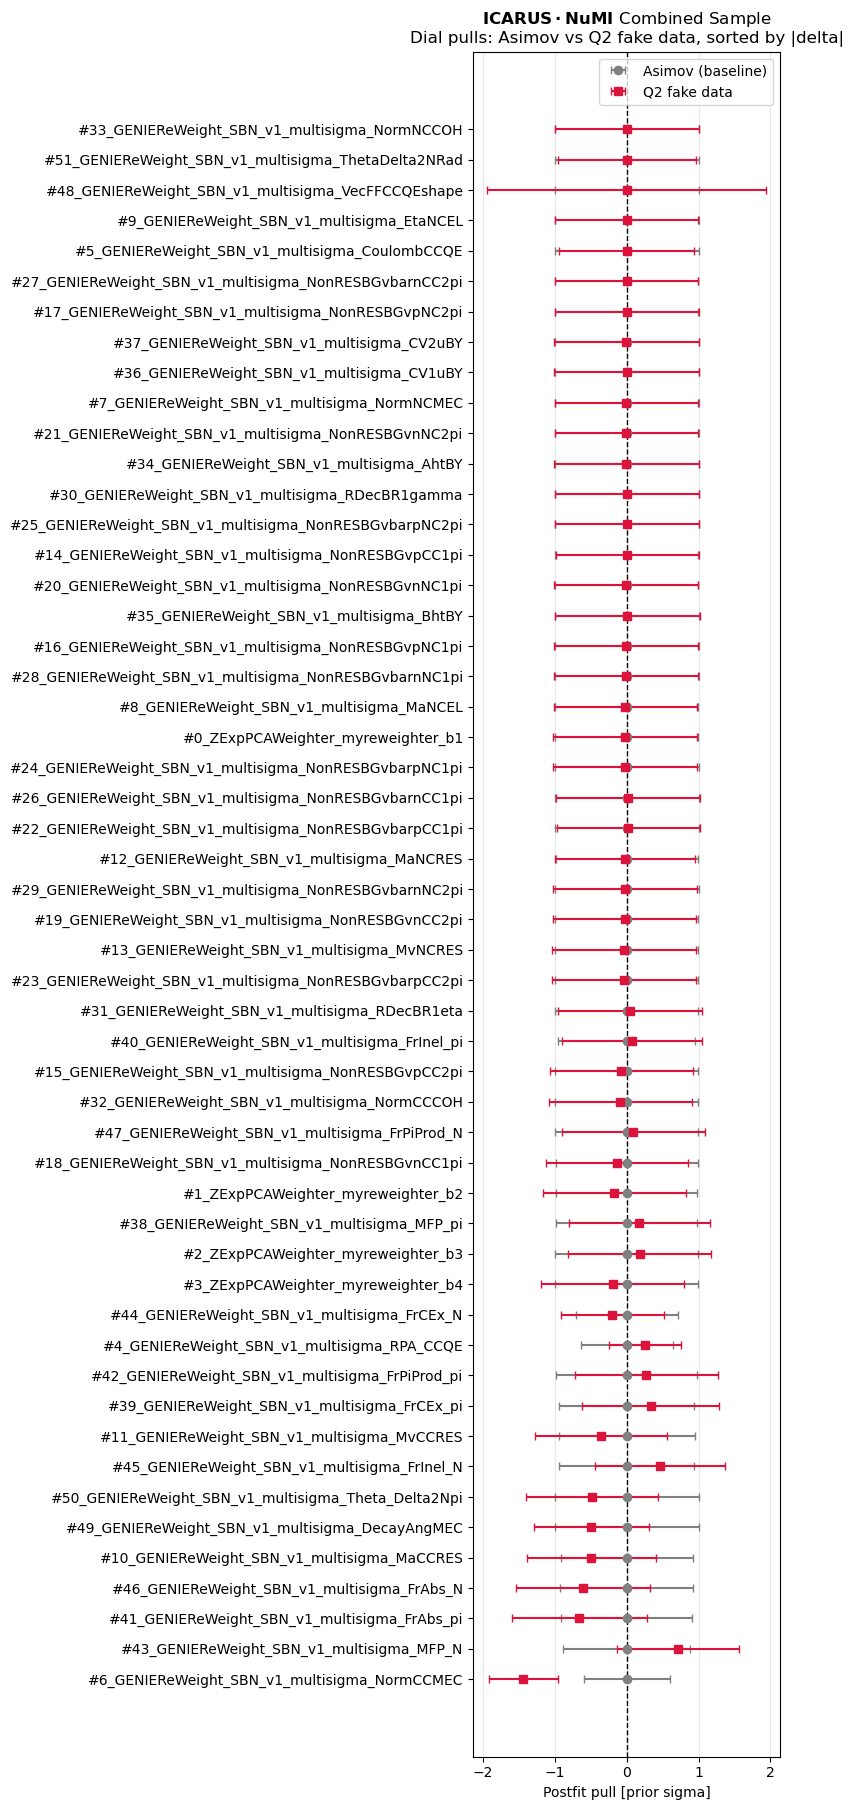

In [44]:
def read_dial_pulls(path, directory='Cross section Systematics'):
    with uproot.open(path) as f:
        h = f[f'FitterEngine/postFit/Hesse/errors/{directory}/values/postFitErrors_TH1D;1']
        values, edges = h.to_numpy()
        errors = h.errors()
        axis = h.axis('x') if hasattr(h, 'axis') else None
        labels = list(axis.labels()) if axis is not None and hasattr(axis, 'labels') else [f'dial_{i}' for i in range(len(values))]
    return labels, values, errors

labels_asimov, pulls_asimov, err_asimov = read_dial_pulls(asimov_combined_path)
labels_q2, pulls_q2, err_q2 = read_dial_pulls(q2_combined_path)

assert labels_asimov == labels_q2, 'Dial ordering differs between the two files -- check by hand before trusting the pairing below.'

delta = pulls_q2 - pulls_asimov
order = np.argsort(-np.abs(delta))

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(labels_asimov))))
y = np.arange(len(labels_asimov))
ax.errorbar(pulls_asimov[order], y, xerr=err_asimov[order], fmt='o', color='gray', label='Asimov (baseline)', capsize=3)
ax.errorbar(pulls_q2[order], y, xerr=err_q2[order], fmt='s', color='crimson', label='Q2 fake data', capsize=3)
ax.set_yticks(y)
ax.set_yticklabels(np.array(labels_asimov)[order])
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Postfit pull [prior sigma]')
ax.set_title(r'$\bf{ICARUS \cdot NuMI}$ Combined Sample' + '\nDial pulls: Asimov vs Q2 fake data, sorted by |delta|')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
save_fig(fig, r'../Plots/dpT/DialStudies', 'combined_dial_pulls_asimov_vs_q2')

print('Top movers (combined sample), sorted by |Q2 pull - Asimov pull|:')
for i in order[:8]:
    print(f'  {labels_asimov[i]:35s}  Asimov={pulls_asimov[i]:+.3f}  Q2={pulls_q2[i]:+.3f}  delta={delta[i]:+.3f}')

## Nuisance Parameter Pulls: Asimov vs. Q2 Fake Data (Containment Split)

Same comparison for the containment fit. Since the template parameter itself pulls differently between combined and containment (~2.0 vs ~1.6 at high dpT, per the previous study), it's worth checking whether that's because a *different* dial is doing the compensating here, or the same one just working less hard.

Top movers (containment split), sorted by |Q2 pull - Asimov pull|:
  #6_GENIEReWeight_SBN_v1_multisigma_NormCCMEC  Asimov=+0.000  Q2=-0.893  delta=-0.893
  #48_GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape  Asimov=+0.000  Q2=-0.747  delta=-0.747
  #43_GENIEReWeight_SBN_v1_multisigma_MFP_N  Asimov=+0.000  Q2=+0.604  delta=+0.604
  #10_GENIEReWeight_SBN_v1_multisigma_MaCCRES  Asimov=-0.000  Q2=-0.581  delta=-0.581
  #41_GENIEReWeight_SBN_v1_multisigma_FrAbs_pi  Asimov=-0.000  Q2=-0.525  delta=-0.525
  #3_ZExpPCAWeighter_myreweighter_b4   Asimov=-0.000  Q2=-0.453  delta=-0.453
  #49_GENIEReWeight_SBN_v1_multisigma_DecayAngMEC  Asimov=-0.000  Q2=+0.438  delta=+0.438
  #2_ZExpPCAWeighter_myreweighter_b3   Asimov=+0.000  Q2=+0.427  delta=+0.427


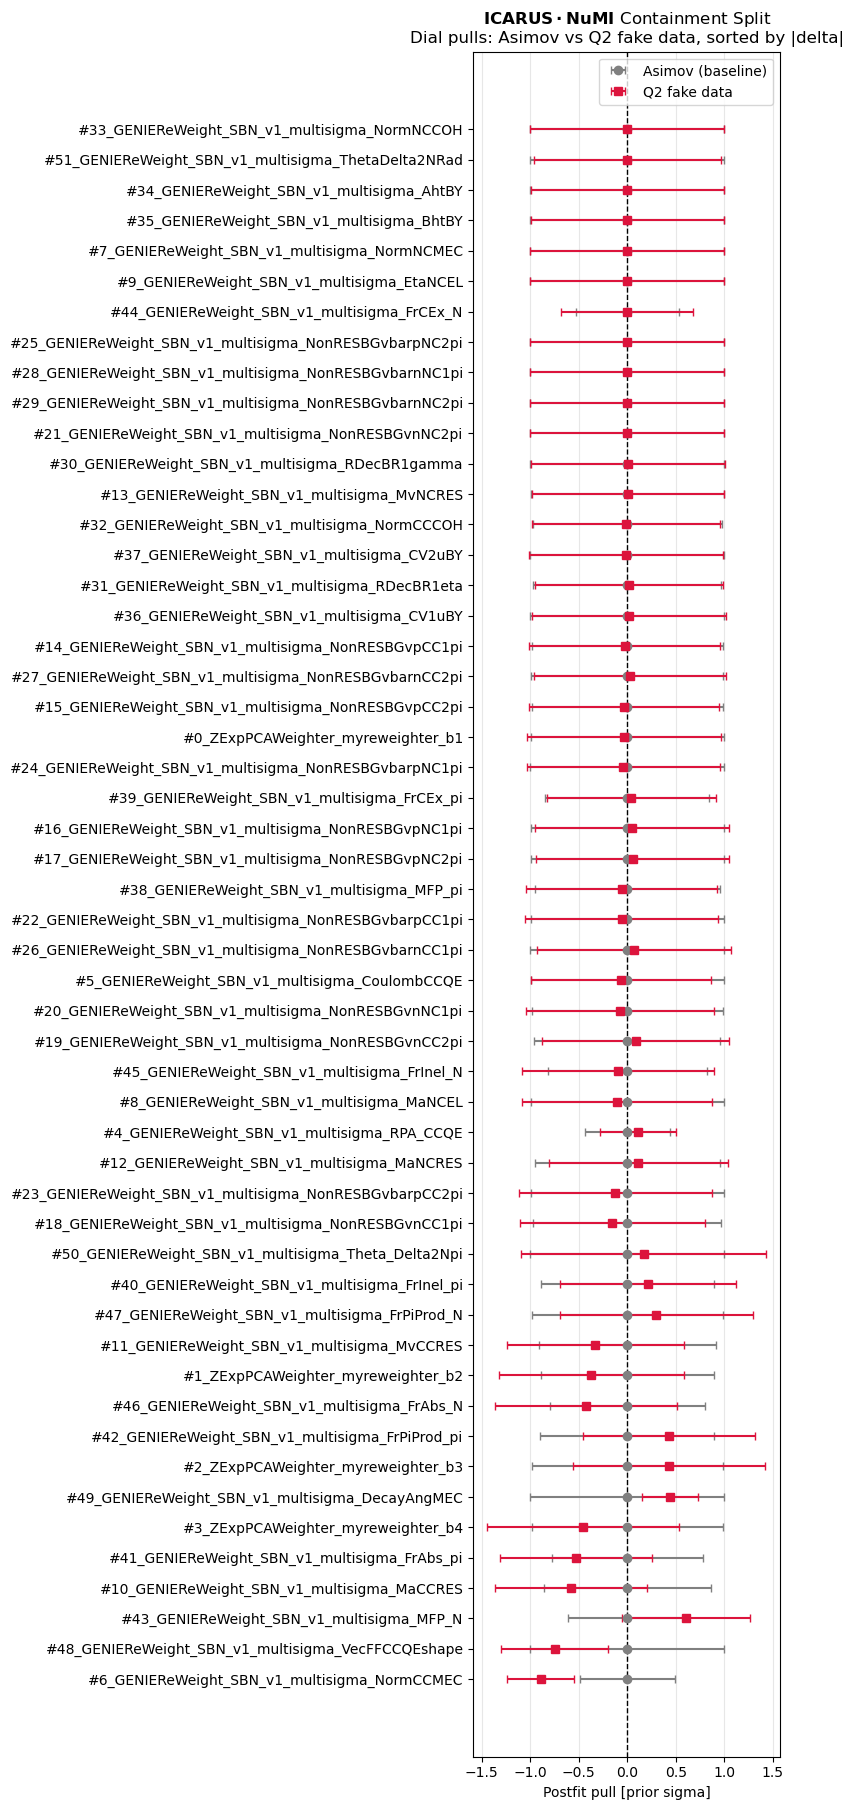

In [45]:
labels_asimov_c, pulls_asimov_c, err_asimov_c = read_dial_pulls(asimov_cont_path)
labels_q2_c, pulls_q2_c, err_q2_c = read_dial_pulls(q2_cont_path)

assert labels_asimov_c == labels_q2_c, 'Dial ordering differs between the two files -- check by hand before trusting the pairing below.'

delta_c = pulls_q2_c - pulls_asimov_c
order_c = np.argsort(-np.abs(delta_c))

fig, ax = plt.subplots(figsize=(8, max(4, 0.35 * len(labels_asimov_c))))
y = np.arange(len(labels_asimov_c))
ax.errorbar(pulls_asimov_c[order_c], y, xerr=err_asimov_c[order_c], fmt='o', color='gray', label='Asimov (baseline)', capsize=3)
ax.errorbar(pulls_q2_c[order_c], y, xerr=err_q2_c[order_c], fmt='s', color='crimson', label='Q2 fake data', capsize=3)
ax.set_yticks(y)
ax.set_yticklabels(np.array(labels_asimov_c)[order_c])
ax.axvline(0, color='black', linestyle='--', linewidth=1)
ax.set_xlabel('Postfit pull [prior sigma]')
ax.set_title(r'$\bf{ICARUS \cdot NuMI}$ Containment Split' + '\nDial pulls: Asimov vs Q2 fake data, sorted by |delta|')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
save_fig(fig, r'../Plots/dpT/DialStudies', 'containment_dial_pulls_asimov_vs_q2')

print('Top movers (containment split), sorted by |Q2 pull - Asimov pull|:')
for i in order_c[:8]:
    print(f'  {labels_asimov_c[i]:35s}  Asimov={pulls_asimov_c[i]:+.3f}  Q2={pulls_q2_c[i]:+.3f}  delta={delta_c[i]:+.3f}')

## Side-by-Side: Does the Same Dial Compensate in Both Fits?

If the combined and containment fits lean on the same dial(s) to the same degree, that's evidence the leakage mechanism is structural (about the missing parameter), not an artifact of one particular binning/sample-split choice.

In [46]:
print(f'{"Dial":35s} {"Combined delta":>16s} {"Containment delta":>19s}')
print('-' * 72)
for label in labels_asimov:
    i_comb = labels_asimov.index(label)
    if label in labels_asimov_c:
        i_cont = labels_asimov_c.index(label)
        print(f'{label:35s} {delta[i_comb]:+16.3f} {delta_c[i_cont]:+19.3f}')
    else:
        print(f'{label:35s} {delta[i_comb]:+16.3f} {"(not found)":>19s}')

Dial                                  Combined delta   Containment delta
------------------------------------------------------------------------
#0_ZExpPCAWeighter_myreweighter_b1            -0.019              -0.032
#1_ZExpPCAWeighter_myreweighter_b2            -0.172              -0.370
#2_ZExpPCAWeighter_myreweighter_b3            +0.180              +0.427
#3_ZExpPCAWeighter_myreweighter_b4            -0.195              -0.453
#4_GENIEReWeight_SBN_v1_multisigma_RPA_CCQE           +0.258              +0.114
#5_GENIEReWeight_SBN_v1_multisigma_CoulombCCQE           -0.002              -0.067
#6_GENIEReWeight_SBN_v1_multisigma_NormCCMEC           -1.436              -0.893
#7_GENIEReWeight_SBN_v1_multisigma_NormNCMEC           -0.003              -0.001
#8_GENIEReWeight_SBN_v1_multisigma_MaNCEL           -0.017              -0.105
#9_GENIEReWeight_SBN_v1_multisigma_EtaNCEL           -0.002              -0.002
#10_GENIEReWeight_SBN_v1_multisigma_MaCCRES           -0.492              

## Raw Dial-to-Dial Correlations (Event-Level, Independent of the Fit)

Different from everything above -- this doesn't touch GUNDAM's output at all. It reads the `multisigma` weight branches directly from the raw ntuple and asks a mechanical question: for two dials A and B, is dial A's per-event weight correlated with dial B's per-event weight, across the selected sample?

**Why this is different from correlating GUNDAM's postfit pulls:** the fit's own Hessian correlations could just be reflecting the compensation we're already trying to diagnose -- circular. This instead measures whether the dials are *mechanically* pulling weight from the same events, independent of any fit. If `NormCCMEC` and `MFP_N` (say) show a strong raw correlation here, that's evidence they're moving together because they genuinely affect overlapping event populations, not because GUNDAM's minimizer coincidentally chose to trade them off.

**Method:** each `GENIEReWeight_SBN_v1_multisigma_<dial>` branch stores a weight per sigma-point per event; the paired `<dial>_sigma` branch gives the actual sigma value at each stored index (order isn't assumed fixed -- located explicitly per dial). Pull the weight at +1sigma for every dial, for every event in the selected sample, then compute the full pairwise Pearson correlation matrix across dials.

In [47]:
ppfx_path = "/Users/rvizarreta/Library/CloudStorage/GoogleDrive-rvizarreta14@gmail.com/My Drive/🏛 PhD Repository/🚀 Research/🤖 Experiments&Projects/ICARUS/ICARUS_CC0pi_Selection/data/icarus_numi_numu_mc_onbeam_offbeam_syst_ppfx.root"
TARGET_SIGMA = 1.0
TREE_PATH = 'events/full/selected_multisigmaTree'  # selection sample; swap to sideband_multisigmaTree to check the sideband instead

with uproot.open(ppfx_path) as f:
    tree = f[TREE_PATH]
    all_branches = tree.keys()
    dial_names = sorted({
        b for b in all_branches
        if b.startswith('GENIEReWeight_SBN_v1_multisigma_') and not b.endswith('_sigma')
    })
    print(f'Found {len(dial_names)} multisigma dials in {TREE_PATH}')

    dial_vectors = {}
    for dial in dial_names:
        weights = tree[dial].array(library='np')
        sigmas = tree[f'{dial}_sigma'].array(library='np')

        wlen = np.array([len(w) for w in weights])
        idx = np.array([np.argmin(np.abs(s - TARGET_SIGMA)) for s in sigmas])

        # A few dials store fewer weights per event than their _sigma branch lists
        # (boolean / shape-only GENIE knobs such as VecFFCCQEshape, DecayAngMEC,
        # Theta_Delta2Npi, ThetaDelta2NRad give one weight per event regardless of the
        # requested sigma point). Clamp to the last stored index instead of assuming a
        # value, so we read whatever GENIE actually computed for that event.
        short = idx >= wlen
        n_short = int(short.sum())
        if n_short > 0:
            tag = 'ALL events' if n_short == len(weights) else f'{n_short}/{len(weights)} events'
            print(f'  NOTE: {dial} -- {tag} store fewer weights than sigma points; '
                  f'using the last stored weight for those events instead of the {TARGET_SIGMA}-sigma point.')
        idx_use = np.minimum(idx, wlen - 1)

        well_formed = ~short
        if well_formed.any():
            actual_sigma_hit = np.array([sigmas[i][idx[i]] for i in range(len(sigmas)) if well_formed[i]])
            if not np.allclose(actual_sigma_hit, TARGET_SIGMA, atol=0.05):
                print(f'  WARNING: {dial} -- requested sigma={TARGET_SIGMA} but closest found is {actual_sigma_hit[0]:.2f} (first well-formed event). Check this dial sigma spacing.')

        dial_vectors[dial] = np.array([weights[i][idx_use[i]] for i in range(len(weights))])

print('Extracted', len(dial_vectors), 'weight vectors, one per dial, length =', len(next(iter(dial_vectors.values()))), 'events')


Found 52 multisigma dials in events/full/selected_multisigmaTree
  NOTE: GENIEReWeight_SBN_v1_multisigma_DecayAngMEC -- ALL events store fewer weights than sigma points; using the last stored weight for those events instead of the 1.0-sigma point.
  NOTE: GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad -- ALL events store fewer weights than sigma points; using the last stored weight for those events instead of the 1.0-sigma point.
  NOTE: GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi -- ALL events store fewer weights than sigma points; using the last stored weight for those events instead of the 1.0-sigma point.
  NOTE: GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape -- ALL events store fewer weights than sigma points; using the last stored weight for those events instead of the 1.0-sigma point.
Extracted 52 weight vectors, one per dial, length = 98983 events


In [48]:
# Diagnostic: inspect the four dials where every event was flagged
# (DecayAngMEC, ThetaDelta2NRad, Theta_Delta2Npi, VecFFCCQEshape)
suspect_dials = [
    'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
    'GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad',
    'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi',
    'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
]

with uproot.open(ppfx_path) as f:
    tree = f[TREE_PATH]
    for dial in suspect_dials:
        weights = tree[dial].array(library='np')
        sigmas = tree[f'{dial}_sigma'].array(library='np')
        wlen = np.array([len(w) for w in weights])
        slen = np.array([len(s) for s in sigmas])
        print(f'=== {dial} ===')
        print(f'  weight-branch lengths: unique={sorted(set(wlen.tolist()))}')
        print(f'  sigma-branch  lengths: unique={sorted(set(slen.tolist()))}')
        print(f'  event 0: weights={weights[0]}, sigmas={sigmas[0]}')
        print(f'  event 1: weights={weights[1]}, sigmas={sigmas[1]}')
        print()


=== GENIEReWeight_SBN_v1_multisigma_DecayAngMEC ===
  weight-branch lengths: unique=[1]
  sigma-branch  lengths: unique=[6]
  event 0: weights=[1.], sigmas=[-1.  1. -2.  2. -3.  3.]
  event 1: weights=[1.], sigmas=[-1.  1. -2.  2. -3.  3.]

=== GENIEReWeight_SBN_v1_multisigma_ThetaDelta2NRad ===
  weight-branch lengths: unique=[1]
  sigma-branch  lengths: unique=[6]
  event 0: weights=[1.], sigmas=[-1.  1. -2.  2. -3.  3.]
  event 1: weights=[1.], sigmas=[-1.  1. -2.  2. -3.  3.]

=== GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi ===
  weight-branch lengths: unique=[1]
  sigma-branch  lengths: unique=[6]
  event 0: weights=[1.], sigmas=[-1.  1. -2.  2. -3.  3.]
  event 1: weights=[1.], sigmas=[-1.  1. -2.  2. -3.  3.]

=== GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape ===
  weight-branch lengths: unique=[1]
  sigma-branch  lengths: unique=[6]
  event 0: weights=[1.], sigmas=[-1.  1. -2.  2. -3.  3.]
  event 1: weights=[0.98340708], sigmas=[-1.  1. -2.  2. -3.  3.]



In [49]:
dial_list = list(dial_vectors.keys())
weight_matrix = np.vstack([dial_vectors[d] for d in dial_list])  # shape (n_dials, n_events)

corr_matrix = np.corrcoef(weight_matrix)

# Dials flagged as movers in the pull-comparison study above -- check what correlates with each
movers = [
    'GENIEReWeight_SBN_v1_multisigma_NormCCMEC',
    'GENIEReWeight_SBN_v1_multisigma_MFP_N',
    'GENIEReWeight_SBN_v1_multisigma_FrAbs_pi',
    'GENIEReWeight_SBN_v1_multisigma_MaCCRES',
    'GENIEReWeight_SBN_v1_multisigma_DecayAngMEC',
    'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape',
    'GENIEReWeight_SBN_v1_multisigma_FrInel_N',
    'GENIEReWeight_SBN_v1_multisigma_Theta_Delta2Npi',
]

for mover in movers:
    if mover not in dial_list:
        print(f'{mover}: not found in this tree, skipping')
        continue
    i = dial_list.index(mover)
    row = corr_matrix[i]
    order = np.argsort(-np.abs(row))
    print(f'{mover} -- top correlated dials (raw event-level weight, excluding self):')
    shown = 0
    for j in order:
        if j == i:
            continue
        print(f'  {dial_list[j]:55s}  r = {row[j]:+.3f}')
        shown += 1
        if shown >= 5:
            break

GENIEReWeight_SBN_v1_multisigma_NormCCMEC -- top correlated dials (raw event-level weight, excluding self):
  GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE               r = -0.507
  GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE               r = +0.403
  GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE               r = +0.275
  GENIEReWeight_SBN_v1_multisigma_MvCCRES                  r = -0.176
  GENIEReWeight_SBN_v1_multisigma_MaCCRES                  r = -0.158
GENIEReWeight_SBN_v1_multisigma_MFP_N -- top correlated dials (raw event-level weight, excluding self):
  GENIEReWeight_SBN_v1_multisigma_FrPiProd_N               r = +0.114
  GENIEReWeight_SBN_v1_multisigma_FrAbs_N                  r = +0.110
  GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE               r = -0.057
  GENIEReWeight_SBN_v1_multisigma_FrCEx_N                  r = -0.057
  GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE               r = +0.051
GENIEReWeight_SBN_v1_multisigma_FrAbs_pi -- top correlated dials (raw event-level weight

/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:2999: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.13/site-packages/numpy/lib/_function_base_impl.py:3000: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


## Does `NormCCMEC` Actually Have Q2 Shape Freedom?

The real question behind the correlations above: is `NormCCMEC` a pure flat normalization (no shape
freedom at all), or does it carry some implicit Q2 dependence? If it's genuinely flat, that's the direct,
structural reason it (and its correlated CCQE-shape neighbors) has to strain to absorb a Q2-shaped
deficit in the Q2 fake-data study -- there is no dedicated 2p2h/MEC dial with Q2 shape freedom in the
model, so the fit is forced to fake the missing shape using a normalization shift plus whatever shape-
capable dials happen to be correlated with it.

First, list candidate branches for true Q2 and interaction mode so we use the right names below.


In [50]:
with uproot.open(ppfx_path) as f:
    tree = f[TREE_PATH]
    all_branches = tree.keys()

candidates_q2 = sorted(b for b in all_branches if 'q2' in b.lower() or 'qsq' in b.lower())
candidates_mode = sorted(b for b in all_branches if any(k in b.lower() for k in ['mode', 'ccmec', 'interaction', 'genie_mode', 'is_mec', 'ismec']))

print('Q2-like branches:')
for b in candidates_q2:
    print(' ', b)
print()
print('Mode/interaction-like branches:')
for b in candidates_mode:
    print(' ', b)


Q2-like branches:

Mode/interaction-like branches:
  GENIEReWeight_SBN_v1_multisigma_NormCCMEC
  GENIEReWeight_SBN_v1_multisigma_NormCCMEC_sigma


In [51]:
with uproot.open(ppfx_path) as f:
    print('Top-level keys in the ppfx file:')
    for k in f.keys():
        print(' ', k)
    print()
    tree = f[TREE_PATH]
    non_dial_branches = sorted(b for b in tree.keys() if not b.startswith('GENIEReWeight_SBN_v1_multisigma_'))
    print(f'Non-multisigma branches in {TREE_PATH} ({len(non_dial_branches)}):')
    for b in non_dial_branches:
        print(' ', b)


Top-level keys in the ppfx file:
  variations;1
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_2d;3
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_2d;2
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA1CCQE_2d;1
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_2d;3
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_2d;2
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA2CCQE_2d;1
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_2d;3
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_2d;2
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA3CCQE_2d;1
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE_2d;3
  variations/reco_leading_muon_ke_GENIEReWeight_SBN_v1_multisigma_ZExpA4CCQE_2d;2
  variations/reco_leading_muon_ke_GENIEReWeight_SB

In [52]:
with uproot.open(ppfx_path) as f:
    sel_tree = f['events/full/selected']
    sel_branches = sel_tree.keys()
    print(f"events/full/selected has {len(sel_branches)} branches, {sel_tree.num_entries} entries")
    print()
    print('Q2-like branches in events/full/selected:')
    for b in sorted(sel_branches):
        if 'q2' in b.lower() or 'qsq' in b.lower():
            print(' ', b)
    print()
    print('mode/interaction-like branches in events/full/selected:')
    for b in sorted(sel_branches):
        if any(k in b.lower() for k in ['mode', 'mec', 'interaction', 'ccqe', 'is_qe', 'isqe']):
            print(' ', b)
    print()

    msig_tree = f[TREE_PATH]
    print(f'{TREE_PATH} entries: {msig_tree.num_entries}')

    # Check whether Evt/Run/Subrun line up 1:1 and in the same order between the two trees
    keys_sel = sel_tree.arrays(['Evt', 'Run', 'Subrun'], library='np')
    keys_msig = msig_tree.arrays(['Evt', 'Run', 'Subrun'], library='np')
    same_length = sel_tree.num_entries == msig_tree.num_entries
    same_order = same_length and all(np.array_equal(keys_sel[k], keys_msig[k]) for k in ['Evt', 'Run', 'Subrun'])
    print(f'same length: {same_length}, same order (row i = same event in both trees): {same_order}')


events/full/selected has 168 branches, 98983 entries

Q2-like branches in events/full/selected:
  reco_Q2
  true_Q2
  true_generator_q2
  true_low_q2_weight

mode/interaction-like branches in events/full/selected:
  true_interaction_mode
  true_interaction_type

events/full/selected_multisigmaTree entries: 98983
same length: True, same order (row i = same event in both trees): True


## Confirming: Does `NormCCMEC` Have Q2 Shape Freedom Within the MEC Sample?

Direct test of the hypothesis: with no dedicated 2p2h/MEC shape dial in the model, `NormCCMEC` is the
*only* MEC-specific knob available, and it should be a pure normalization -- flat across Q2 within the
MEC sample. If confirmed, that's the mechanistic reason it's forced to shift when the fit sees a
Q2-shaped deficit: it has no way to change shape, so it moves as a flat rescale and leaves residual
Q2-dependence for the (structurally unrelated) CCQE-shape/FSI dials found in the correlation study.

Step 1: identify which `true_interaction_mode` value corresponds to MEC empirically, using the fact
that `NormCCMEC` should give weight != 1 almost exclusively for MEC events (self-consistency check,
no guessing GENIE's mode-code convention).


In [53]:
with uproot.open(ppfx_path) as f:
    sel_tree = f['events/full/selected']
    q2 = sel_tree['true_Q2'].array(library='np')
    mode = sel_tree['true_interaction_mode'].array(library='np')
    itype = sel_tree['true_interaction_type'].array(library='np')

    msig_tree = f[TREE_PATH]
    weights = msig_tree['GENIEReWeight_SBN_v1_multisigma_NormCCMEC'].array(library='np')

# earlier we found this dial stores exactly one weight per event
w = np.array([wi[0] for wi in weights])
affected = ~np.isclose(w, 1.0, atol=1e-6)
print(f'{affected.sum()} / {len(w)} events have NormCCMEC weight != 1.0')
print()

print('Fraction of events with NormCCMEC weight != 1, by true_interaction_mode:')
frac_by_mode = {}
for m in np.unique(mode):
    sel = mode == m
    frac = affected[sel].mean()
    frac_by_mode[m] = frac
    print(f'  mode={m!r:>6}  n={sel.sum():>7}  frac_affected={frac:.3f}')

mec_mode = max(frac_by_mode, key=frac_by_mode.get)
print()
print(f'--> inferred MEC mode code: {mec_mode!r} (frac_affected={frac_by_mode[mec_mode]:.3f})')
assert frac_by_mode[mec_mode] > 0.9, 'no mode value is cleanly MEC-dominated -- stop and inspect true_interaction_type instead'

# Step 2: within that MEC subset, is the weight flat vs true Q2, or does it carry shape?
mec_sel = mode == mec_mode
w_mec = w[mec_sel]
q2_mec = q2[mec_sel]

print()
print(f'MEC subset: {mec_sel.sum()} events. NormCCMEC weight (all should be ~1+delta, a flat rescale if this is a pure norm dial):')
print(f'  mean={w_mec.mean():.4f}  std={w_mec.std():.6f}  min={w_mec.min():.4f}  max={w_mec.max():.4f}')

q2_bins = np.quantile(q2_mec, np.linspace(0, 1, 9))  # 8 equal-population bins
bin_idx = np.digitize(q2_mec, q2_bins[1:-1])
print()
print(f'{"Q2 bin":>22s}  {"n":>7s}  {"mean weight":>12s}  {"std weight":>11s}')
for b in range(8):
    sel = bin_idx == b
    if sel.sum() == 0:
        continue
    lo, hi = q2_bins[b], q2_bins[b+1]
    print(f'  [{lo:6.3f}, {hi:6.3f})   {sel.sum():>7d}  {w_mec[sel].mean():>12.5f}  {w_mec[sel].std():>11.6f}')


19376 / 98983 events have NormCCMEC weight != 1.0

Fraction of events with NormCCMEC weight != 1, by true_interaction_mode:
  mode=np.float64(0.0)  n=  58294  frac_affected=0.000
  mode=np.float64(1.0)  n=  18153  frac_affected=0.000
  mode=np.float64(2.0)  n=   3076  frac_affected=0.001
  mode=np.float64(3.0)  n=     69  frac_affected=0.000
  mode=np.float64(10.0)  n=  19391  frac_affected=0.998

--> inferred MEC mode code: np.float64(10.0) (frac_affected=0.998)

MEC subset: 19391 events. NormCCMEC weight (all should be ~1+delta, a flat rescale if this is a pure norm dial):
  mean=0.5011  std=0.023245  min=0.5000  max=1.0000

                Q2 bin        n   mean weight   std weight
  [   nan,    nan)        19       0.60526     0.203841
  [   nan,    nan)     19372       0.50098     0.022123


In [54]:
# Fix: true_Q2 has NaNs/placeholders for some MEC events, which poisoned np.quantile above.
print(f'q2_mec: {len(q2_mec)} events, {np.isnan(q2_mec).sum()} NaN, '
      f'{(q2_mec < 0).sum() if not np.isnan(q2_mec).all() else 0} negative (placeholder?) among non-NaN')
finite = np.isfinite(q2_mec) & (q2_mec >= 0)
print(f'{finite.sum()} / {len(q2_mec)} MEC events have a usable true_Q2')

w_clean = w_mec[finite]
q2_clean = q2_mec[finite]

print()
print(f'Clean MEC subset: mean={w_clean.mean():.4f}  std={w_clean.std():.6f}  min={w_clean.min():.4f}  max={w_clean.max():.4f}')

q2_bins = np.quantile(q2_clean, np.linspace(0, 1, 9))  # 8 equal-population bins
bin_idx = np.digitize(q2_clean, q2_bins[1:-1])
print()
print(f'{"Q2 bin":>22s}  {"n":>7s}  {"mean weight":>12s}  {"std weight":>11s}')
for b in range(8):
    sel = bin_idx == b
    if sel.sum() == 0:
        continue
    lo, hi = q2_bins[b], q2_bins[b+1]
    print(f'  [{lo:6.3f}, {hi:6.3f})   {sel.sum():>7d}  {w_clean[sel].mean():>12.5f}  {w_clean[sel].std():>11.6f}')


q2_mec: 19391 events, 19 NaN, 0 negative (placeholder?) among non-NaN
19372 / 19391 MEC events have a usable true_Q2

Clean MEC subset: mean=0.5010  std=0.022123  min=0.5000  max=1.0000

                Q2 bin        n   mean weight   std weight
  [ 0.040,  0.601)      2422       0.50062     0.017586
  [ 0.601,  1.244)      2421       0.50083     0.020307
  [ 1.244,  2.207)      2422       0.50041     0.014362
  [ 2.207,  3.496)      2421       0.50145     0.026847
  [ 3.496,  5.058)      2421       0.50083     0.020307
  [ 5.058,  7.003)      2422       0.50145     0.026841
  [ 7.003, 10.631)      2421       0.50207     0.032068
  [10.631, 279.009)      2422       0.50021     0.010158


## Exploring the Available 2p2h Dials

A teammate's earlier chat flagged three knobs that look like they could give the MEC sector real Q2/
shape freedom, unlike the flat `NormCCMEC`:
- `MINERvAE2p2h_SBN_v1_E2p2h_A_nu` / `_B_nu` -- MINERvA-derived 2p2h "Gaussian enhancement" shape
  parameters (an event-by-event fit-based reweighting of the 2p2h strength as a function of
  interaction kinematics, from MINERvA's own MEC tune)
- `MINERvAg0q3Weighting_SBN_v1_Mnv202hGaussEnhancement` -- a related MINERvA (q0,q3) 2p2h enhancement
  weighting
- `MiscInteractionSysts_SBN_v1_C12ToAr40_2p2hScaling_nu` -- a target-nucleus rescaling of the 2p2h
  strength going from MINERvA's carbon target to ICARUS's argon

First step: find out where these actually live in the ntuple (multisigma vs multisim tree), and what
shape/type they are, before assuming anything about how to use them.


In [55]:
candidates = [
    'MINERvAE2p2h_SBN_v1_E2p2h_A_nu',
    'MINERvAE2p2h_SBN_v1_E2p2h_B_nu',
    'MINERvAg0q3Weighting_SBN_v1_Mnv202hGaussEnhancement',
    'MiscInteractionSysts_SBN_v1_C12ToAr40_2p2hScaling_nu',
]

trees_to_check = [
    'events/full/selected_multisigmaTree',
    'events/full/selected_multisimTree',
    'events/full/selected_variationTree',
]

with uproot.open(ppfx_path) as f:
    for tpath in trees_to_check:
        tree = f[tpath]
        branches = tree.keys()
        print(f'=== {tpath} ({tree.num_entries} entries) ===')
        for cand in candidates:
            matches = sorted(b for b in branches if cand in b)
            if matches:
                for m in matches:
                    arr = tree[m].array(library='np', entry_stop=5)
                    lens = [len(x) if hasattr(x, '__len__') else None for x in arr]
                    print(f'  FOUND: {m}  (sample lengths: {lens})')
            else:
                print(f'  not found: {cand}')
        print()


=== events/full/selected_multisigmaTree (98983 entries) ===
  not found: MINERvAE2p2h_SBN_v1_E2p2h_A_nu
  not found: MINERvAE2p2h_SBN_v1_E2p2h_B_nu
  not found: MINERvAg0q3Weighting_SBN_v1_Mnv202hGaussEnhancement
  not found: MiscInteractionSysts_SBN_v1_C12ToAr40_2p2hScaling_nu

=== events/full/selected_multisimTree (98983 entries) ===
  FOUND: MINERvAE2p2h_SBN_v1_E2p2h_A_nu  (sample lengths: [6, 6, 6, 6, 6])
  FOUND: MINERvAE2p2h_SBN_v1_E2p2h_A_nubar  (sample lengths: [6, 6, 6, 6, 6])
  FOUND: MINERvAE2p2h_SBN_v1_E2p2h_B_nu  (sample lengths: [6, 6, 6, 6, 6])
  FOUND: MINERvAE2p2h_SBN_v1_E2p2h_B_nubar  (sample lengths: [6, 6, 6, 6, 6])
  FOUND: MINERvAg0q3Weighting_SBN_v1_Mnv202hGaussEnhancement  (sample lengths: [4, 4, 4, 4, 4])
  FOUND: MiscInteractionSysts_SBN_v1_C12ToAr40_2p2hScaling_nu  (sample lengths: [6, 6, 6, 6, 6])
  FOUND: MiscInteractionSysts_SBN_v1_C12ToAr40_2p2hScaling_nubar  (sample lengths: [6, 6, 6, 6, 6])

=== events/full/selected_variationTree (98983 entries) ===
  n

In [56]:
candidates_nu = [
    'MINERvAE2p2h_SBN_v1_E2p2h_A_nu',
    'MINERvAE2p2h_SBN_v1_E2p2h_B_nu',
    'MINERvAg0q3Weighting_SBN_v1_Mnv202hGaussEnhancement',
    'MiscInteractionSysts_SBN_v1_C12ToAr40_2p2hScaling_nu',
]

with uproot.open(ppfx_path) as f:
    sel_tree = f['events/full/selected']
    q2 = sel_tree['true_Q2'].array(library='np')
    mode = sel_tree['true_interaction_mode'].array(library='np')

    msim_tree = f['events/full/selected_multisimTree']
    mec_sel = (mode == 10.0) & np.isfinite(q2) & (q2 >= 0)
    print(f'MEC events with usable Q2: {mec_sel.sum()}')
    print()

    for dial in candidates_nu:
        arr = msim_tree[dial].array(library='np')
        n_univ = np.array([len(x) for x in arr])
        assert np.all(n_univ == n_univ[0]), 'ragged universes -- handle separately'
        mat = np.vstack(arr)  # shape (n_events, n_universes)

        affected = ~np.all(np.isclose(mat, 1.0, atol=1e-6), axis=1)
        frac_mec = affected[mode == 10.0].mean()
        frac_nonmec = affected[mode != 10.0].mean()
        print(f'=== {dial} ({mat.shape[1]} universes) ===')
        print(f'  fraction of events affected: MEC={frac_mec:.3f}, non-MEC={frac_nonmec:.3f}')

        mat_mec = mat[mec_sel]
        q2_mec = q2[mec_sel]
        per_event_mean = mat_mec.mean(axis=1)   # central value across universes, per event
        per_event_std = mat_mec.std(axis=1)     # universe spread, per event -- the actual uncertainty

        q2_bins = np.quantile(q2_mec, np.linspace(0, 1, 7))  # 6 equal-population bins
        bin_idx = np.digitize(q2_mec, q2_bins[1:-1])
        print(f'  {"Q2 bin":>22s}  {"n":>6s}  {"<mean weight>":>14s}  {"<universe std>":>15s}')
        for b in range(6):
            sel = bin_idx == b
            if sel.sum() == 0:
                continue
            lo, hi = q2_bins[b], q2_bins[b+1]
            print(f'    [{lo:6.3f}, {hi:6.3f})  {sel.sum():>6d}  {per_event_mean[sel].mean():>14.5f}  {per_event_std[sel].mean():>15.5f}')
        print()


MEC events with usable Q2: 19372

=== MINERvAE2p2h_SBN_v1_E2p2h_A_nu (6 universes) ===
  fraction of events affected: MEC=0.898, non-MEC=0.000
                  Q2 bin       n   <mean weight>   <universe std>
    [ 0.040,  0.779)    3229         0.37054          0.32198
    [ 0.779,  1.857)    3228         1.00987          1.34616
    [ 1.857,  3.496)    3229         1.44910          1.64635
    [ 3.496,  5.657)    3228         1.67750          1.52819
    [ 5.657,  8.950)    3229         1.25841          0.63143
    [ 8.950, 279.009)    3229         1.05726          0.21964

=== MINERvAE2p2h_SBN_v1_E2p2h_B_nu (6 universes) ===
  fraction of events affected: MEC=0.898, non-MEC=0.000
                  Q2 bin       n   <mean weight>   <universe std>
    [ 0.040,  0.779)    3229         1.49097          1.76391
    [ 0.779,  1.857)    3228         1.71990          1.57991
    [ 1.857,  3.496)    3229         1.27920          0.66316
    [ 3.496,  5.657)    3228         1.14867          0.

## Ground Truth: What Was Actually Injected, and Where

Pulled directly from `dataSetListConfig_FakeData_Q2.yaml` -- this is the literal formula GUNDAM's toy
generator applies, not a guess:

```
(true_generator_q2 < 0 || true_generator_q2 > 0.7 || category not in {4,5,6,7}) ? 1.0
  : 1.0 - 0.7 * (1 - f(true_generator_q2))^2,
  f(Q2) = -0.6*Q2*(Q2-0.7)/0.1225 + Q2*(Q2-0.35)/0.245
```

Important: `category` 4-7 is **"Other CC"** background (per `plotConfigs_reco_dpT.yaml`: numuCC Np1pi /
uncontained-fiducial / uncontained / generic nu CC -- topologies that fail the Np0pi signal selection),
*not* the MEC signal category (which is category 1). And the gating variable is `true_generator_q2`,
a separate branch from `true_Q2`. So before testing whether the 2p2h dials (gated on
`true_interaction_mode == 10`) could absorb this, we need to know how much the two selections actually
overlap -- if most of the injected-affected events aren't MEC-mode at all, those dials structurally
cannot reach them, regardless of their Q2 shape.


In [58]:
with uproot.open(ppfx_path) as f:
    sel_tree = f['events/full/selected']
    q2gen = sel_tree['true_generator_q2'].array(library='np')
    category = sel_tree['true_category'].array(library='np')
    mode = sel_tree['true_interaction_mode'].array(library='np')

def f_shape(q2):
    return -0.6*q2*(q2-0.7)/0.1225 + q2*(q2-0.35)/0.245

in_cat = np.isin(category, [4, 5, 6, 7])
in_q2 = (q2gen >= 0.0) & (q2gen <= 0.7)
injected_mask = in_cat & in_q2

ratio = np.ones_like(q2gen)
ratio[injected_mask] = 1.0 - 0.7 * (1.0 - f_shape(q2gen[injected_mask]))**2

print(f'Total selected events: {len(q2gen)}')
print(f'Events actually hit by the injection (category in 4-7 AND 0<=true_generator_q2<=0.7): {injected_mask.sum()} ({injected_mask.mean()*100:.2f}%)')
print(f'  of those, injected ratio range: [{ratio[injected_mask].min():.3f}, {ratio[injected_mask].max():.3f}], mean={ratio[injected_mask].mean():.3f}')
print()

print('Breakdown of injected-affected events by true_interaction_mode:')
for m in np.unique(mode[injected_mask]):
    sel = injected_mask & (mode == m)
    print(f'  mode={m!r:>6}  n={sel.sum():>6}  ({sel.sum()/injected_mask.sum()*100:.1f}% of injected-affected)')
print()

n_mec_and_injected = (injected_mask & (mode == 10.0)).sum()
n_mec_total = (mode == 10.0).sum()
print(f'MEC events that are ALSO hit by the injection: {n_mec_and_injected} / {n_mec_total} MEC events total '
      f'({n_mec_and_injected/n_mec_total*100:.1f}% of all MEC events)')
print(f'Injected-affected events that are MEC: {n_mec_and_injected} / {injected_mask.sum()} '
      f'({n_mec_and_injected/injected_mask.sum()*100:.1f}% of all injected-affected events)')


Total selected events: 98983
Events actually hit by the injection (category in 4-7 AND 0<=true_generator_q2<=0.7): 5590 (5.65%)
  of those, injected ratio range: [0.302, 1.000], mean=0.769

Breakdown of injected-affected events by true_interaction_mode:
  mode=np.float64(0.0)  n=  1024  (18.3% of injected-affected)
  mode=np.float64(1.0)  n=  3519  (63.0% of injected-affected)
  mode=np.float64(2.0)  n=   767  (13.7% of injected-affected)
  mode=np.float64(3.0)  n=    69  (1.2% of injected-affected)
  mode=np.float64(10.0)  n=   211  (3.8% of injected-affected)

MEC events that are ALSO hit by the injection: 211 / 19391 MEC events total (1.1% of all MEC events)
Injected-affected events that are MEC: 211 / 5590 (3.8% of all injected-affected events)


In [59]:
with uproot.open(q2_combined_path) as f:
    def walk(node, prefix='', depth=0, maxdepth=5):
        if depth > maxdepth:
            return
        try:
            keys = node.keys(recursive=False)
        except Exception:
            return
        for k in keys:
            full = f'{prefix}/{k}' if prefix else k
            print(full)
            try:
                sub = node[k]
            except Exception:
                continue
            if hasattr(sub, 'keys'):
                walk(sub, full, depth+1, maxdepth)
    walk(f)


gundam;1
gundam;1/runtime;1
gundam;1/runtime;1/date_TNamed;1
gundam;1/runtime;1/user_TNamed;1
gundam;1/runtime;1/host_TNamed;1
gundam;1/runtime;1/pwd_TNamed;1
gundam;1/runtime;1/os_TNamed;1
gundam;1/runtime;1/dist_TNamed;1
gundam;1/runtime;1/arch_TNamed;1
gundam;1/runtime;1/commandLine_TNamed;1
gundam;1/build;1
gundam;1/build;1/version_TNamed;1
gundam;1/build;1/root;1
gundam;1/build;1/root;1/version_TNamed;1
gundam;1/build;1/root;1/date_TNamed;1
gundam;1/build;1/root;1/install_TNamed;1
gundam;1/config;1
gundam;1/config;1/unfoldedJson_TNamed;1
FitterEngine;1
FitterEngine;1/preFit;1
FitterEngine;1/preFit;1/parameters;1
FitterEngine;1/preFit;1/parameters;1/throws_TTree;1
FitterEngine;1/preFit;1/parameters;1/throws_TTree;1/Template_Parameter_true_dpT_lp_genie
FitterEngine;1/preFit;1/parameters;1/throws_TTree;1/Cross_section_Systematics
FitterEngine;1/preFit;1/parameters;1/throws_TTree;1/Multisigma_Flux_Systematics
FitterEngine;1/preFit;1/parameters;1/throws_TTree;1/Detector_Systematics
Fit

## Direct Test: Can the 2p2h Dials Absorb the Injected Q2 Shift, in Reco Bins?

Built straight from `events/full/selected`, using the exact same bin edges and cut GUNDAM uses
(`binning_reco_dpT.txt`, `cut_type==1`) and the exact nominal weight formula from
`dataSetListConfig_FakeData_Q2.yaml` (`ppfx_cv_weight`), so this reproduces the actual reco-binned
prediction the fitter sees -- no detector response matrix needed, since `reco_dpT_lp` in the ntuple
already carries the reconstruction.

Steps:
1. Build the nominal and Q2-fake-data predicted `reco_dpT_lp` histograms directly (same formula as the
   toy generator config). Their difference is the real non-closure shape that needs to be explained.
2. Build a reco-binned "response template" per dial: reweight the nominal histogram by each dial's
   per-event weight and take the difference from nominal. For the 2p2h multisim dials (no single
   "+1sigma" point), use the per-event mean deviation across universes as the template's shape.
3. Least-squares fit the deficit as a linear combination of dial templates, and report how much of the
   deficit shape is explained (R^2-like metric), plus the residual after fitting.


In [62]:
bin_edges = np.array([
    0.0, 88.80410, 135.0000, 188.7780, 246.0000, 293.9020, 352.0000,
    404.3560, 465.0000, 523.3890, 598.0000, 677.3210, 800.0000, 99999.00
])

with uproot.open(ppfx_path) as f:
    sel_tree = f['events/full/selected']
    arrs = sel_tree.arrays(['reco_dpT_lp', 'true_generator_q2', 'true_category', 'ppfx_cv_weight'], library='np')
    reco_dpT = arrs['reco_dpT_lp']
    q2gen = arrs['true_generator_q2']
    category = arrs['true_category']
    w_nom = arrs['ppfx_cv_weight']

    msim_tree = f['events/full/selected_multisimTree']
    w_2p2h_A = np.vstack(msim_tree['MINERvAE2p2h_SBN_v1_E2p2h_A_nu'].array(library='np'))
    w_2p2h_B = np.vstack(msim_tree['MINERvAE2p2h_SBN_v1_E2p2h_B_nu'].array(library='np'))

    msig_tree = f[TREE_PATH]
    w_normccmec = np.array([w[0] for w in msig_tree['GENIEReWeight_SBN_v1_multisigma_NormCCMEC'].array(library='np')])

cut = np.ones(len(reco_dpT), dtype=bool)  # no cut_type selection -- ignored per instruction

# injected fake-data weight (identical formula to dataSetListConfig_FakeData_Q2.yaml)
def f_shape(q2):
    return -0.6*q2*(q2-0.7)/0.1225 + q2*(q2-0.35)/0.245
in_cat = np.isin(category, [4, 5, 6, 7])
in_q2 = (q2gen >= 0.0) & (q2gen <= 0.7)
injected_mask = in_cat & in_q2
ratio = np.ones_like(q2gen)
ratio[injected_mask] = 1.0 - 0.7*(1.0 - f_shape(q2gen[injected_mask]))**2
w_fake = w_nom * ratio

def hist(values, weights):
    h, _ = np.histogram(values[cut], bins=bin_edges, weights=weights[cut])
    return h

h_nominal = hist(reco_dpT, w_nom)
h_fakedata = hist(reco_dpT, w_fake)
deficit = h_fakedata - h_nominal

# dial templates: reweighted histogram minus nominal, same binning
template_normccmec = hist(reco_dpT, w_nom * w_normccmec) - h_nominal
mean_dev_A = w_2p2h_A.mean(axis=1) - 1.0
mean_dev_B = w_2p2h_B.mean(axis=1) - 1.0
template_2p2h_A = hist(reco_dpT, w_nom * (1.0 + mean_dev_A)) - h_nominal
template_2p2h_B = hist(reco_dpT, w_nom * (1.0 + mean_dev_B)) - h_nominal

print()
print(f'{"bin":>18s}  {"nominal":>10s}  {"fake data":>10s}  {"deficit":>10s}  {"tmpl NormCCMEC":>15s}  {"tmpl 2p2h A":>12s}  {"tmpl 2p2h B":>12s}')
for i in range(len(bin_edges)-1):
    lo, hi = bin_edges[i], bin_edges[i+1]
    print(f'  [{lo:7.1f},{hi:8.1f})  {h_nominal[i]:>10.2f}  {h_fakedata[i]:>10.2f}  {deficit[i]:>10.2f}  '
          f'{template_normccmec[i]:>15.3f}  {template_2p2h_A[i]:>12.3f}  {template_2p2h_B[i]:>12.3f}')

print()
print(f'Total deficit (sum over bins): {deficit.sum():.2f}')
print(f'||deficit||: {np.linalg.norm(deficit):.3f}')

# least squares: deficit ~ c1*template_2p2h_A + c2*template_2p2h_B
X_2p2h = np.column_stack([template_2p2h_A, template_2p2h_B])
coef_2p2h, res_2p2h, rank, sv = np.linalg.lstsq(X_2p2h, deficit, rcond=None)
pred_2p2h = X_2p2h @ coef_2p2h
resid_2p2h = deficit - pred_2p2h
r2_2p2h = 1 - np.sum(resid_2p2h**2) / np.sum(deficit**2)
print()
print(f'2p2h-only fit: coefficients (A, B) = {coef_2p2h}, R^2-like fraction of deficit explained = {r2_2p2h:.3f}')
print(f'residual after 2p2h fit: {resid_2p2h}')

# for comparison: NormCCMEC alone
X_mec = template_normccmec.reshape(-1, 1)
coef_mec, _, _, _ = np.linalg.lstsq(X_mec, deficit, rcond=None)
pred_mec = X_mec @ coef_mec
resid_mec = deficit - pred_mec
r2_mec = 1 - np.sum(resid_mec**2) / np.sum(deficit**2)
print()
print(f'NormCCMEC-only fit: coefficient = {coef_mec}, R^2-like fraction explained = {r2_mec:.3f}')

# combined: NormCCMEC + 2p2h A + B together
X_all = np.column_stack([template_normccmec, template_2p2h_A, template_2p2h_B])
coef_all, _, _, _ = np.linalg.lstsq(X_all, deficit, rcond=None)
pred_all = X_all @ coef_all
resid_all = deficit - pred_all
r2_all = 1 - np.sum(resid_all**2) / np.sum(deficit**2)
print()
print(f'NormCCMEC + 2p2h A + B combined fit: coefficients = {coef_all}, R^2-like fraction explained = {r2_all:.3f}')



               bin     nominal   fake data     deficit   tmpl NormCCMEC   tmpl 2p2h A   tmpl 2p2h B
  [    0.0,    88.8)     8596.75     8532.05      -64.70         -286.726        11.428       198.666
  [   88.8,   135.0)     8639.44     8567.41      -72.03         -337.655        48.538       205.671
  [  135.0,   188.8)    11059.19    10948.83     -110.36         -539.865        64.964       338.294
  [  188.8,   246.0)    11287.73    11157.00     -130.73         -759.014       101.724       479.457
  [  246.0,   293.9)     7961.68     7864.33      -97.34         -734.758       109.770       447.038
  [  293.9,   352.0)     8128.46     8006.98     -121.48         -953.205       212.095       579.928
  [  352.0,   404.4)     6217.43     6118.59      -98.83         -840.483       180.170       501.012
  [  404.4,   465.0)     6269.78     6169.30     -100.49         -900.625       230.782       563.051
  [  465.0,   523.4)     4863.91     4778.48      -85.43         -756.423       235

## Full Comparison: Which Dial Groups Can Explain the Deficit, and How Much Does 2p2h Add?

Raw R^2-like "fraction explained" is misleading on its own -- more free parameters always fit better,
and we already showed a MEC-only dial can fake most of a *smooth* deficit through reco-space geometry
even with almost no true-level overlap with the injected events. Two extra things are needed for a fair
verdict:
- **Marginal improvement**: does adding 2p2h on top of the RES/FSI cluster (which *does* touch the true
  injected population) improve the fit beyond what RES/FSI alone already achieves?
- **Statistical significance of what's left over**: is the post-fit residual compatible with pure
  Poisson noise (sqrt(N) per bin), or is it still a real, structured mismatch?

Dial templates reuse `dial_vectors` from the earlier +1sigma extraction cell (built once, robust to the
short-weight-vector dials), reweighted into the same reco `dpT` binning and cut used above.


In [63]:
def make_template(dial_key):
    w = dial_vectors[dial_key]
    return hist(reco_dpT, w_nom * w) - h_nominal

groups = {
    'NormCCMEC only':            ['GENIEReWeight_SBN_v1_multisigma_NormCCMEC'],
    '2p2h A+B only':              None,  # filled below (not in dial_vectors, computed separately)
    'RES cluster (Ma/MvCCRES)':  ['GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES'],
    'FSI-pi cluster':            ['GENIEReWeight_SBN_v1_multisigma_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_pi',
                                   'GENIEReWeight_SBN_v1_multisigma_FrInel_pi', 'GENIEReWeight_SBN_v1_multisigma_FrCEx_pi'],
    'RES + FSI-pi':               ['GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES',
                                   'GENIEReWeight_SBN_v1_multisigma_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_pi',
                                   'GENIEReWeight_SBN_v1_multisigma_FrInel_pi', 'GENIEReWeight_SBN_v1_multisigma_FrCEx_pi'],
    'RES + FSI-pi + NormCCMEC':  ['GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES',
                                   'GENIEReWeight_SBN_v1_multisigma_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_pi',
                                   'GENIEReWeight_SBN_v1_multisigma_FrInel_pi', 'GENIEReWeight_SBN_v1_multisigma_FrCEx_pi',
                                   'GENIEReWeight_SBN_v1_multisigma_NormCCMEC'],
    'Full existing movers (+VecFFCCQEshape)': ['GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES',
                                   'GENIEReWeight_SBN_v1_multisigma_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_pi',
                                   'GENIEReWeight_SBN_v1_multisigma_FrInel_pi', 'GENIEReWeight_SBN_v1_multisigma_FrCEx_pi',
                                   'GENIEReWeight_SBN_v1_multisigma_NormCCMEC', 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape'],
}

sigma_nom = np.sqrt(np.maximum(h_nominal, 1.0))  # Poisson-like per-bin uncertainty
ndof_raw = len(deficit)
chi2_raw = np.sum((deficit / sigma_nom)**2)
print(f'Raw non-closure significance (no dials applied): chi2/ndof = {chi2_raw:.1f} / {ndof_raw}')
print()

def fit_and_report(name, templates_2d, n_extra_free=0):
    X = np.column_stack(templates_2d)
    coef, _, _, _ = np.linalg.lstsq(X, deficit, rcond=None)
    pred = X @ coef
    resid = deficit - pred
    r2 = 1 - np.sum(resid**2) / np.sum(deficit**2)
    chi2 = np.sum((resid / sigma_nom)**2)
    ndof = len(deficit) - X.shape[1]
    print(f'{name:42s}  n_par={X.shape[1]:2d}  R2={r2:6.3f}  post-fit chi2/ndof = {chi2:6.2f} / {ndof}')
    return r2, chi2, coef

results = {}
for name, keys in groups.items():
    if keys is None:
        continue
    templates = [make_template(k) for k in keys]
    results[name] = fit_and_report(name, templates)

# 2p2h-only and combos involving 2p2h (built from the earlier mean-deviation templates)
templates_2p2h = [template_2p2h_A, template_2p2h_B]
results['2p2h A+B only'] = fit_and_report('2p2h A+B only', templates_2p2h)

resfsi_keys = ['GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES',
               'GENIEReWeight_SBN_v1_multisigma_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_pi',
               'GENIEReWeight_SBN_v1_multisigma_FrInel_pi', 'GENIEReWeight_SBN_v1_multisigma_FrCEx_pi']
resfsi_templates = [make_template(k) for k in resfsi_keys]
results['RES + FSI-pi + 2p2h A+B'] = fit_and_report('RES + FSI-pi + 2p2h A+B', resfsi_templates + templates_2p2h)

full_movers_keys = ['GENIEReWeight_SBN_v1_multisigma_MaCCRES', 'GENIEReWeight_SBN_v1_multisigma_MvCCRES',
               'GENIEReWeight_SBN_v1_multisigma_MFP_pi', 'GENIEReWeight_SBN_v1_multisigma_FrAbs_pi',
               'GENIEReWeight_SBN_v1_multisigma_FrInel_pi', 'GENIEReWeight_SBN_v1_multisigma_FrCEx_pi',
               'GENIEReWeight_SBN_v1_multisigma_NormCCMEC', 'GENIEReWeight_SBN_v1_multisigma_VecFFCCQEshape']
full_movers_templates = [make_template(k) for k in full_movers_keys]
results['Full existing movers + 2p2h A+B'] = fit_and_report('Full existing movers + 2p2h A+B', full_movers_templates + templates_2p2h)

print()
print('Marginal R2 gain from adding 2p2h A+B on top of RES+FSI-pi:      '
      f'{results["RES + FSI-pi + 2p2h A+B"][0] - results["RES + FSI-pi"][0]:+.3f}')
print('Marginal R2 gain from adding 2p2h A+B on top of full existing movers: '
      f'{results["Full existing movers + 2p2h A+B"][0] - results["Full existing movers (+VecFFCCQEshape)"][0]:+.3f}')


Raw non-closure significance (no dials applied): chi2/ndof = 17.2 / 13

NormCCMEC only                              n_par= 1  R2= 0.946  post-fit chi2/ndof =   0.71 / 12
RES cluster (Ma/MvCCRES)                    n_par= 2  R2= 0.976  post-fit chi2/ndof =   0.38 / 11
FSI-pi cluster                              n_par= 4  R2= 0.992  post-fit chi2/ndof =   0.17 / 9
RES + FSI-pi                                n_par= 6  R2= 0.995  post-fit chi2/ndof =   0.12 / 7
RES + FSI-pi + NormCCMEC                    n_par= 7  R2= 0.995  post-fit chi2/ndof =   0.11 / 6
Full existing movers (+VecFFCCQEshape)      n_par= 8  R2= 0.996  post-fit chi2/ndof =   0.09 / 5
2p2h A+B only                               n_par= 2  R2= 0.962  post-fit chi2/ndof =   0.56 / 11
RES + FSI-pi + 2p2h A+B                     n_par= 8  R2= 0.998  post-fit chi2/ndof =   0.04 / 5
Full existing movers + 2p2h A+B             n_par=10  R2= 1.000  post-fit chi2/ndof =   0.00 / 3

Marginal R2 gain from adding 2p2h A+B on top of RES

## Survey: What Other Dials Exist in the File But Aren't in the Fit?

Compares the dials actually present in the ppfx ntuple (multisigma and multisim trees) against the
parameters currently in `Configs_ParameterSetList/parameterSetList_true_dpT.yaml` (read back from the
fitter output file itself, not retyped by hand, to avoid transcription mistakes).


In [ ]:
import re

# 1) dials currently in the fit, read directly from the fitter output file
with uproot.open(q2_combined_path) as f:
    xsec_keys = f['FitterEngine/propagator/Cross section Systematics/parameters'].keys(recursive=False)

def strip_index_prefix(raw_key):
    bare = raw_key.split(';')[0].split('/')[-1]
    parts = bare.split('_', 1)
    if len(parts) == 2 and parts[0].isdigit():
        return parts[1]
    return bare

fitted_names = sorted({strip_index_prefix(k) for k in xsec_keys})
print(f'{len(fitted_names)} cross-section dials currently in the fit')
print('sample:', fitted_names[:3])

# 2) all dial families present in the ppfx ntuple
with uproot.open(ppfx_path) as f:
    msig_branches = f['events/full/selected_multisigmaTree'].keys()
    msim_branches = f['events/full/selected_multisimTree'].keys()

msig_dials = sorted({b for b in msig_branches if not b.endswith('_sigma') and b not in ('Evt', 'Run', 'Subrun')})
msim_dials = sorted({b for b in msim_branches if b not in ('Evt', 'Run', 'Subrun')})

available = set(msig_dials) | set(msim_dials)
fitted_set = set(fitted_names)
print('intersection size (sanity check, should be ~48):', len(available & fitted_set))

missing = sorted(available - fitted_set)
print(f'{len(available)} dial branches available in the ntuple (multisigma + multisim), {len(missing)} NOT currently in the fit')
print()

# group the missing ones by family prefix for readability
families = {}
for name in missing:
    prefix = name.split('_SBN_v1_')[0] if '_SBN_v1_' in name else name.split('_')[0]
    families.setdefault(prefix, []).append(name)

for fam in sorted(families):
    members = families[fam]
    print(f'{fam}  ({len(members)} branches)')
    for m in sorted(members)[:6]:
        print(f'    {m}')
    if len(members) > 6:
        print(f'    ... and {len(members)-6} more')
    print()


## Testing `SPPLowQ2Suppression` as a candidate dedicated dial

Flagged from the availability survey above: `MiscInteractionSysts_SBN_v1_SPPLowQ2Suppression`, a multisim dial (10 universes) that is not currently in the fit. By name it targets low-Q2 single-pion-production suppression, which matches the RES/DIS-dominated character of the injected Q2 fake-data effect more directly than the 2p2h dials tested earlier. Same methodology as the 2p2h test: mean-deviation-across-universes template, least-squares fit to the reco-level deficit, R2 and Poisson-like chi2/ndof reported alongside the existing-mover baselines.

In [67]:
with uproot.open(ppfx_path) as f:
    msim_tree = f['events/full/selected_multisimTree']
    w_sppq2 = np.vstack(msim_tree['MiscInteractionSysts_SBN_v1_SPPLowQ2Suppression'].array(library='np'))

nonunity_sppq2 = (np.abs(w_sppq2 - 1.0) > 1e-6).any(axis=1)
n_inj = injected_mask.sum()
n_spp = nonunity_sppq2.sum()
n_both = (injected_mask & nonunity_sppq2).sum()
print(f'injected-population events: {n_inj}')
print(f'SPPLowQ2Suppression-affected events: {n_spp}')
print(f'true-level overlap: {n_both} ({100*n_both/n_inj:.2f}% of injected events, {100*n_both/n_spp:.2f}% of SPP-affected events)')
print('(compare to the 5.65% true-level overlap found for the 2p2h dials above)')


injected-population events: 5590
SPPLowQ2Suppression-affected events: 12680
true-level overlap: 3325 (59.48% of injected events, 26.22% of SPP-affected events)
(compare to the 5.65% true-level overlap found for the 2p2h dials above)


In [68]:
mean_dev_sppq2 = w_sppq2.mean(axis=1) - 1.0
template_sppq2 = hist(reco_dpT, w_nom * (1.0 + mean_dev_sppq2)) - h_nominal

results['SPPLowQ2Suppression only'] = fit_and_report('SPPLowQ2Suppression only', [template_sppq2])
results['RES + FSI-pi + SPPLowQ2Suppression'] = fit_and_report('RES + FSI-pi + SPPLowQ2Suppression', resfsi_templates + [template_sppq2])
results['Full existing movers + SPPLowQ2Suppression'] = fit_and_report('Full existing movers + SPPLowQ2Suppression', full_movers_templates + [template_sppq2])
results['Full existing movers + SPPLowQ2Suppression + 2p2h A+B'] = fit_and_report(
    'Full existing movers + SPPLowQ2Suppression + 2p2h A+B', full_movers_templates + [template_sppq2] + templates_2p2h)

print()
print('Marginal R2 gain, SPPLowQ2Suppression on top of RES+FSI-pi:        '
      f'{results["RES + FSI-pi + SPPLowQ2Suppression"][0] - results["RES + FSI-pi"][0]:+.4f}')
print('Marginal R2 gain, SPPLowQ2Suppression on top of full existing movers: '
      f'{results["Full existing movers + SPPLowQ2Suppression"][0] - results["Full existing movers (+VecFFCCQEshape)"][0]:+.4f}')
print()
print('NOTE: the marginal gain on top of already-fitted movers is small because RES+FSI-pi is already near-saturating the fit '
      '(R2=0.995 with 6 free parameters). The more telling comparison is standalone efficiency: SPPLowQ2Suppression alone, '
      'with a SINGLE free parameter, reaches R2~0.986 -- comparable to what the 6-parameter RES+FSI-pi cluster achieves. '
      'Combined with the 59% true-level overlap with the injected population (vs 5.65% for 2p2h), this is a materially '
      'stronger case for a dedicated dial than the 2p2h test above.')


SPPLowQ2Suppression only                    n_par= 1  R2= 0.986  post-fit chi2/ndof =   0.21 / 12
RES + FSI-pi + SPPLowQ2Suppression          n_par= 7  R2= 0.998  post-fit chi2/ndof =   0.03 / 6
Full existing movers + SPPLowQ2Suppression  n_par= 9  R2= 1.000  post-fit chi2/ndof =   0.01 / 4
Full existing movers + SPPLowQ2Suppression + 2p2h A+B  n_par=11  R2= 1.000  post-fit chi2/ndof =   0.00 / 2

Marginal R2 gain, SPPLowQ2Suppression on top of RES+FSI-pi:        +0.0036
Marginal R2 gain, SPPLowQ2Suppression on top of full existing movers: +0.0037

NOTE: the marginal gain on top of already-fitted movers is small because RES+FSI-pi is already near-saturating the fit (R2=0.995 with 6 free parameters). The more telling comparison is standalone efficiency: SPPLowQ2Suppression alone, with a SINGLE free parameter, reaches R2~0.986 -- comparable to what the 6-parameter RES+FSI-pi cluster achieves. Combined with the 59% true-level overlap with the injected population (vs 5.65% for 2p2h), this 

### Why the marginal gain is small: reco-space degeneracy check

The small marginal R2 gain from adding `SPPLowQ2Suppression` on top of RES+FSI-pi does not mean the dial is redundant at the true level (59% true-level overlap with the injected population says otherwise). It means its reco-binned shape is largely spanned by the 6-dimensional space already covered by MaCCRES/MvCCRES/MFP_pi/FrAbs_pi/FrInel_pi/FrCEx_pi. Checked directly: project the SPPLowQ2Suppression template onto the span of the 6 RES+FSI-pi templates via least squares.

In [ ]:
print(f"{'dial':40s}  corr with SPPLowQ2Suppression shape")
for k, t in zip(resfsi_keys, resfsi_templates):
    r = np.corrcoef(t, template_sppq2)[0, 1]
    print(f'{k:40s}  {r:+.3f}')

X = np.column_stack(resfsi_templates)
coef, res, rank, sv = np.linalg.lstsq(X, template_sppq2, rcond=None)
proj = X @ coef
r2_span = 1 - np.sum((template_sppq2 - proj)**2) / np.sum(template_sppq2**2)
print()
print(f'Fraction of SPPLowQ2Suppression template shape already spanned by RES+FSI-pi (6-dim space): R2={r2_span:.4f}')
print()
print('Interpretation: the small marginal R2 gain above is a reco-space degeneracy effect, not evidence that the dial '
      'is physically redundant. The true-level overlap (59%) and single-parameter standalone efficiency (R2=0.986) '
      'remain the primary evidence for a dedicated dial; the reco-level fit alone cannot distinguish "genuinely needed" '
      'from "already spanned by existing flexible templates" without this true-level cross-check.')


## The real issue: sideband-driven stress leaking into the template (cross-section) parameters

None of the available dials -- existing or candidate (2p2h, SPPLowQ2Suppression) -- fully absorb the Q2 fake-data stress without residual reco-level tension. The next question is where that unabsorbed stress actually goes. Two checks: (1) how much of the injected suppression lands in the sideband sample vs the signal selection sample, since the sideband is a background-dominated control region by design; (2) how much the true-dpT template (cross-section) parameters themselves get pulled between the Asimov and Q2 fake-data fits, using the same `read_dial_pulls` helper pointed at the `Template Parameter true_dpT_lp_genie` directory instead of `Cross section Systematics`.

In [ ]:
def f_shape(q2): return -0.6*q2*(q2-0.7)/0.1225 + q2*(q2-0.35)/0.245

def summarize_injection(tree_name):
    with uproot.open(ppfx_path) as f:
        tr = f[f'events/full/{tree_name}']
        arrs = tr.arrays(['true_generator_q2', 'true_category', 'ppfx_cv_weight'], library='np')
    q2gen = arrs['true_generator_q2']; category = arrs['true_category']; w = arrs['ppfx_cv_weight']
    in_cat = np.isin(category, [4, 5, 6, 7])
    in_q2 = (q2gen >= 0.0) & (q2gen <= 0.7)
    injected_mask = in_cat & in_q2
    ratio = np.ones_like(q2gen)
    ratio[injected_mask] = 1.0 - 0.7*(1.0 - f_shape(q2gen[injected_mask]))**2
    w_fake = w * ratio
    n_tot = len(q2gen); n_inj = injected_mask.sum()
    frac_events = n_inj / n_tot
    total_deficit_frac = (w.sum() - w_fake.sum()) / w.sum()
    print(f'{tree_name:12s}  n_tot={n_tot:7d}  n_injected={n_inj:6d} ({100*frac_events:5.2f}% of events)  '
          f'total event-weighted deficit={100*total_deficit_frac:5.2f}%')

print('Fraction of events in the injected population (category in {4,5,6,7}, true_generator_q2 in [0, 0.7])')
print('and the resulting total normalization deficit, per sample -- using the SAME injection formula GUNDAM')
print('applies to both datasets per dataSetListConfig_FakeData_Q2.yaml:')
for t in ['selected', 'sideband']:
    summarize_injection(t)


In [ ]:
TEMPLATE_DIR = 'Template Parameter true_dpT_lp_genie'

la_t, pa_t, ea_t = read_dial_pulls(asimov_combined_path, TEMPLATE_DIR)
lq_t, pq_t, eq_t = read_dial_pulls(q2_combined_path, TEMPLATE_DIR)
lac_t, pac_t, eac_t = read_dial_pulls(asimov_cont_path, TEMPLATE_DIR)
lqc_t, pqc_t, eqc_t = read_dial_pulls(q2_cont_path, TEMPLATE_DIR)

print('True-dpT template (cross-section) parameter pulls -- COMBINED sample')
print(f'{"bin":6s} {"Asimov":>10s} {"Q2 fake":>10s} {"delta":>10s}')
for i in range(len(la_t)):
    print(f'{la_t[i]:6s} {pa_t[i]:+10.3f} {pq_t[i]:+10.3f} {pq_t[i]-pa_t[i]:+10.3f}')

print()
print('True-dpT template (cross-section) parameter pulls -- CONTAINMENT split')
print(f'{"bin":6s} {"Asimov":>10s} {"Q2 fake":>10s} {"delta":>10s}')
for i in range(len(lac_t)):
    print(f'{lac_t[i]:6s} {pac_t[i]:+10.3f} {pqc_t[i]:+10.3f} {pqc_t[i]-pac_t[i]:+10.3f}')

print()
print('These are the actual measured cross-section normalizations in bins of true dpT. A dedicated systematic dial that '
      'cannot fully absorb the sideband-driven stress leaves the fit to relieve tension by pulling these parameters '
      'directly -- which is a bias on the measurement itself, not just a chi2/ndof problem.')
